In [1]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
import torchvision.transforms as transforms


In [2]:
dataset_dir = "Fabric Defect Dataset"  # Change if needed
if not os.path.exists(dataset_dir):
    raise FileNotFoundError(f"{dataset_dir} does not exist!")
print(f"Dataset directory found: {dataset_dir}")


Dataset directory found: Fabric Defect Dataset


In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])


In [4]:
class FabricBinaryDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        for cls in os.listdir(root_dir):
            cls_path = os.path.join(root_dir, cls)
            if not os.path.isdir(cls_path):
                continue
            label = 0 if cls.lower() == "defect free" else 1
            for file in os.listdir(cls_path):
                if file.lower().endswith(('.png','.jpg','.jpeg')):
                    self.samples.append((os.path.join(cls_path, file), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)


In [5]:
dataset_stage1 = FabricBinaryDataset(dataset_dir, transform=transform)
print("Stage1 Dataset samples:", len(dataset_stage1))

train_size = int(0.8 * len(dataset_stage1))
val_size = len(dataset_stage1) - train_size
train_dataset_stage1, val_dataset_stage1 = random_split(dataset_stage1, [train_size, val_size])


Stage1 Dataset samples: 2739


In [6]:
labels = [label for _, label in train_dataset_stage1]
class_counts = torch.bincount(torch.tensor(labels))
weights = 1. / class_counts.float()
sample_weights = [weights[label] for label in labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)


In [7]:
train_loader_stage1 = DataLoader(train_dataset_stage1, batch_size=32, sampler=sampler, num_workers=0, pin_memory=True)
val_loader_stage1 = DataLoader(val_dataset_stage1, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)


In [8]:
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim

# Stage 1 Model: Binary Classification
class Stage1BinaryModel(nn.Module):
    def __init__(self, pretrained=True):
        super(Stage1BinaryModel, self).__init__()
        self.backbone = models.resnet18(pretrained=pretrained)
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(num_ftrs, 2)  # 2 classes: Defect / Defect-Free

    def forward(self, x):
        return self.backbone(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_stage1 = Stage1BinaryModel(pretrained=True).to(device)
print(model_stage1)


Stage1BinaryModel(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True

c:\ProgramData\anaconda3\envs\fabric_gpu\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\ProgramData\anaconda3\envs\fabric_gpu\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [9]:
criterion_stage1 = nn.CrossEntropyLoss()
optimizer_stage1 = optim.Adam(model_stage1.parameters(), lr=1e-4)
scheduler_stage1 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_stage1, mode='min', factor=0.5, patience=3, verbose=True)


c:\ProgramData\anaconda3\envs\fabric_gpu\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [10]:
num_epochs = 10  # adjust as needed

for epoch in range(num_epochs):
    # ---- Training ----
    model_stage1.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for images, labels in train_loader_stage1:
        images, labels = images.to(device), labels.to(device)
        optimizer_stage1.zero_grad()
        outputs = model_stage1(images)
        loss = criterion_stage1(outputs, labels)
        loss.backward()
        optimizer_stage1.step()

        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_acc = train_correct / train_total
    train_loss /= train_total

    # ---- Validation ----
    model_stage1.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader_stage1:
            images, labels = images.to(device), labels.to(device)
            outputs = model_stage1(images)
            loss = criterion_stage1(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    val_loss /= val_total

    scheduler_stage1.step(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")


Epoch [1/10] | Train Loss: 0.0958, Train Acc: 0.9580 | Val Loss: 0.0498, Val Acc: 0.9818
Epoch [2/10] | Train Loss: 0.0500, Train Acc: 0.9808 | Val Loss: 0.0376, Val Acc: 0.9854
Epoch [3/10] | Train Loss: 0.0422, Train Acc: 0.9836 | Val Loss: 0.0370, Val Acc: 0.9836
Epoch [4/10] | Train Loss: 0.0176, Train Acc: 0.9950 | Val Loss: 0.0384, Val Acc: 0.9854
Epoch [5/10] | Train Loss: 0.0199, Train Acc: 0.9932 | Val Loss: 0.0459, Val Acc: 0.9799
Epoch [6/10] | Train Loss: 0.0181, Train Acc: 0.9941 | Val Loss: 0.0407, Val Acc: 0.9799
Epoch [7/10] | Train Loss: 0.0229, Train Acc: 0.9932 | Val Loss: 0.0256, Val Acc: 0.9854
Epoch [8/10] | Train Loss: 0.0179, Train Acc: 0.9927 | Val Loss: 0.0382, Val Acc: 0.9836
Epoch [9/10] | Train Loss: 0.0153, Train Acc: 0.9954 | Val Loss: 0.0322, Val Acc: 0.9872
Epoch [10/10] | Train Loss: 0.0032, Train Acc: 0.9986 | Val Loss: 0.0444, Val Acc: 0.9872


In [11]:
class FabricDefectDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        for cls in os.listdir(root_dir):
            cls_path = os.path.join(root_dir, cls)
            if not os.path.isdir(cls_path) or cls.lower() == "defect free":
                continue  # only defect classes
            label = cls  # keep class name for now
            for file in os.listdir(cls_path):
                if file.lower().endswith(('.png','.jpg','.jpeg')):
                    self.samples.append((os.path.join(cls_path, file), label))

        # Create mapping from class name -> integer
        self.classes = sorted(list(set([label for _, label in self.samples])))
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label_name = self.samples[idx]
        label = self.class_to_idx[label_name]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

# Stage 2 dataset
dataset_stage2 = FabricDefectDataset(dataset_dir, transform=transform)
print("Stage2 Dataset samples:", len(dataset_stage2))
print("Stage2 Classes:", dataset_stage2.classes)

train_size = int(0.8 * len(dataset_stage2))
val_size = len(dataset_stage2) - train_size
train_dataset_stage2, val_dataset_stage2 = random_split(dataset_stage2, [train_size, val_size])

# Weighted sampler for imbalanced classes
labels = [label for _, label in train_dataset_stage2]
class_counts = torch.bincount(torch.tensor(labels))
weights = 1. / class_counts.float()
sample_weights = [weights[label] for label in labels]
sampler_stage2 = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader_stage2 = DataLoader(train_dataset_stage2, batch_size=32, sampler=sampler_stage2, num_workers=0, pin_memory=True)
val_loader_stage2 = DataLoader(val_dataset_stage2, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)


Stage2 Dataset samples: 1073
Stage2 Classes: ['Vertical', 'hole', 'horizontal', 'lines', 'stain']


In [12]:
class Stage2MultiClassModel(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super(Stage2MultiClassModel, self).__init__()
        self.backbone = models.resnet18(pretrained=pretrained)
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(num_ftrs, num_classes)

    def forward(self, x):
        return self.backbone(x)

num_classes_stage2 = len(dataset_stage2.classes)
model_stage2 = Stage2MultiClassModel(num_classes=num_classes_stage2, pretrained=True).to(device)
print(model_stage2)


Stage2MultiClassModel(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=

In [13]:
criterion_stage2 = nn.CrossEntropyLoss()
optimizer_stage2 = optim.Adam(model_stage2.parameters(), lr=1e-4)
scheduler_stage2 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_stage2, mode='min', factor=0.5, patience=3, verbose=True)


In [14]:
num_epochs_stage2 = 15  # adjust based on dataset

for epoch in range(num_epochs_stage2):
    # ---- Training ----
    model_stage2.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for images, labels in train_loader_stage2:
        images, labels = images.to(device), labels.to(device)
        optimizer_stage2.zero_grad()
        outputs = model_stage2(images)
        loss = criterion_stage2(outputs, labels)
        loss.backward()
        optimizer_stage2.step()

        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_acc = train_correct / train_total
    train_loss /= train_total

    # ---- Validation ----
    model_stage2.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader_stage2:
            images, labels = images.to(device), labels.to(device)
            outputs = model_stage2(images)
            loss = criterion_stage2(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    val_loss /= val_total

    scheduler_stage2.step(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs_stage2}] | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")


Epoch [1/15] | Train Loss: 0.5739, Train Acc: 0.7867 | Val Loss: 0.2537, Val Acc: 0.9302
Epoch [2/15] | Train Loss: 0.1526, Train Acc: 0.9499 | Val Loss: 0.1877, Val Acc: 0.9442
Epoch [3/15] | Train Loss: 0.1173, Train Acc: 0.9615 | Val Loss: 0.1856, Val Acc: 0.9442
Epoch [4/15] | Train Loss: 0.0537, Train Acc: 0.9848 | Val Loss: 0.1355, Val Acc: 0.9535
Epoch [5/15] | Train Loss: 0.0364, Train Acc: 0.9918 | Val Loss: 0.1580, Val Acc: 0.9674
Epoch [6/15] | Train Loss: 0.0249, Train Acc: 0.9930 | Val Loss: 0.1640, Val Acc: 0.9721
Epoch [7/15] | Train Loss: 0.0602, Train Acc: 0.9860 | Val Loss: 0.1101, Val Acc: 0.9814
Epoch [8/15] | Train Loss: 0.0397, Train Acc: 0.9895 | Val Loss: 0.1189, Val Acc: 0.9721
Epoch [9/15] | Train Loss: 0.0143, Train Acc: 0.9977 | Val Loss: 0.1368, Val Acc: 0.9767
Epoch [10/15] | Train Loss: 0.0134, Train Acc: 0.9977 | Val Loss: 0.2004, Val Acc: 0.9488
Epoch [11/15] | Train Loss: 0.0111, Train Acc: 0.9977 | Val Loss: 0.1204, Val Acc: 0.9767
Epoch [12/15] | Tra

In [17]:
def evaluate_stage1(model, dataloader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    acc = correct / total
    print(f"Stage 1 Accuracy (Binary): {acc:.4f}")
    return acc


def evaluate_stage2(model, dataloader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    acc = correct / total
    print(f"Stage 2 Accuracy (Multi-class): {acc:.4f}")
    return acc


def evaluate_two_stage(model_stage1, model_stage2, val_loader_stage1, val_loader_stage2, device):
    model_stage1.eval()
    model_stage2.eval()
    overall_correct, overall_total = 0, 0

    with torch.no_grad():
        # Evaluate defect-free + defect detection
        for images, labels in val_loader_stage1:
            images, labels = images.to(device), labels.to(device)
            outputs = model_stage1(images)
            preds = torch.argmax(outputs, dim=1)

            for i in range(len(labels)):
                if labels[i] == 0:  # true defect-free
                    if preds[i] == 0:
                        overall_correct += 1
                else:  # true defective
                    if preds[i] == 1:  # passed to stage2
                        # Run through stage2
                        img = images[i].unsqueeze(0)
                        true_label = labels[i].item() - 1  # shift (1→0, 2→1, etc.)
                        stage2_pred = torch.argmax(model_stage2(img), dim=1).item()
                        if stage2_pred == true_label:
                            overall_correct += 1
                overall_total += 1

    overall_acc = overall_correct / overall_total
    print(f"Overall Two-Stage Accuracy: {overall_acc:.4f}")
    return overall_acc


In [18]:
acc1 = evaluate_stage1(model_stage1, val_loader_stage1, device)
acc2 = evaluate_stage2(model_stage2, val_loader_stage2, device)
overall = evaluate_two_stage(model_stage1, model_stage2, val_loader_stage1, val_loader_stage2, device)


Stage 1 Accuracy (Binary): 0.9872
Stage 2 Accuracy (Multi-class): 0.9767
Overall Two-Stage Accuracy: 0.6606


In [22]:
import torch
import pickle

# --- Stage 1 predictions and true labels ---
stage1_preds, stage1_trues = [], []
model_stage1.eval()
with torch.no_grad():
    for images, labels in val_loader_stage1:
        images, labels = images.to(device), labels.to(device)
        outputs = model_stage1(images)
        preds = torch.argmax(outputs, dim=1)
        stage1_preds.extend(preds.cpu().tolist())
        stage1_trues.extend(labels.cpu().tolist())

# --- Stage 2 predictions and true labels ---
stage2_preds, stage2_trues = [], []
model_stage2.eval()
with torch.no_grad():
    for images, labels in val_loader_stage2:
        images, labels = images.to(device), labels.to(device)
        outputs = model_stage2(images)
        preds = torch.argmax(outputs, dim=1)
        stage2_preds.extend(preds.cpu().tolist())
        stage2_trues.extend(labels.cpu().tolist())

# --- Stage 1 → Stage 2 propagated predictions ---
two_stage_preds, two_stage_trues = [], []
model_stage1.eval()
model_stage2.eval()
with torch.no_grad():
    for images, labels in val_loader_stage1:
        images, labels = images.to(device), labels.to(device)
        outputs = model_stage1(images)
        preds = torch.argmax(outputs, dim=1)
        
        for i in range(len(labels)):
            true_label = labels[i].item()
            if true_label == 0:  # defect-free
                two_stage_preds.append(preds[i].item())
            else:  # defective
                if preds[i] == 1:  # passed to stage 2
                    img = images[i].unsqueeze(0)
                    stage2_pred = torch.argmax(model_stage2(img), dim=1).item()
                    two_stage_preds.append(stage2_pred + 1)  # shift to match original labels
                else:
                    two_stage_preds.append(preds[i].item())
            two_stage_trues.append(true_label)

# --- Save everything ---
history = {
    'stage1_preds': stage1_preds,
    'stage1_trues': stage1_trues,
    'stage2_preds': stage2_preds,
    'stage2_trues': stage2_trues,
    'two_stage_preds': two_stage_preds,
    'two_stage_trues': two_stage_trues,
    'stage2_class_mapping': dataset_stage2.class_to_idx
}

with open('saved_history.pkl', 'wb') as f:
    pickle.dump(history, f)

print("✅ History saved successfully to 'saved_history.pkl'")


✅ History saved successfully to 'saved_history.pkl'


Result Plots:

In [20]:
# Stage 1 labels (binary: 0 = defect-free, 1 = defect)
stage1_labels = [label for _, label in dataset_stage1.samples]

# Stage 2 labels (multiclass, use integer indices)
stage2_labels = [dataset_stage2.class_to_idx[label] for _, label in dataset_stage2.samples]

print("Stage 1 label counts:", torch.bincount(torch.tensor(stage1_labels)))
print("Stage 2 label counts:", torch.bincount(torch.tensor(stage2_labels)))


Stage 1 label counts: tensor([1666, 1073])
Stage 2 label counts: tensor([101, 281, 136, 157, 398])


C:\Users\r\AppData\Local\Temp\ipykernel_4668\1892721791.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=stage1_labels, palette="Set2")


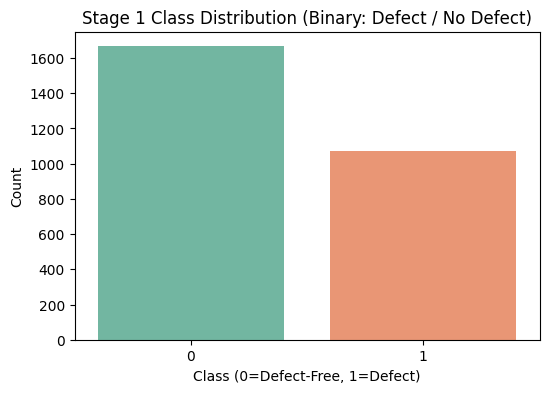

C:\Users\r\AppData\Local\Temp\ipykernel_4668\1892721791.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=stage2_labels, palette="Set3")


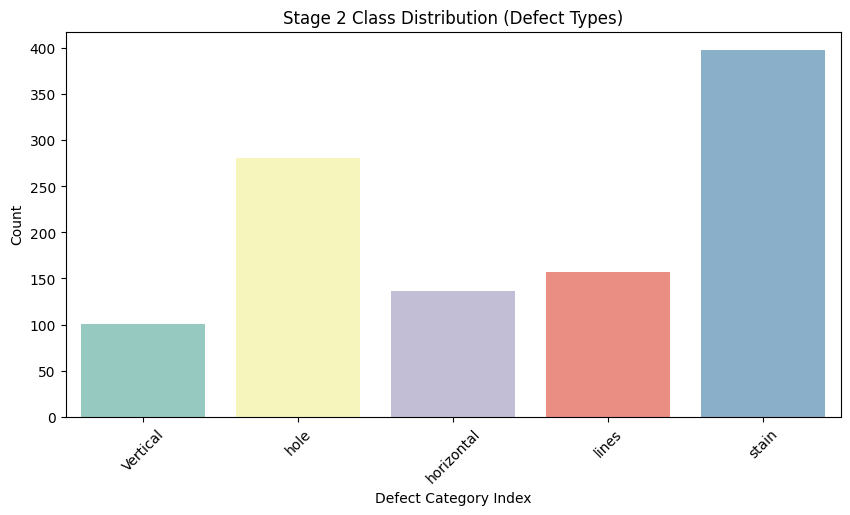

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Stage 1 binary distribution
plt.figure(figsize=(6,4))
sns.countplot(x=stage1_labels, palette="Set2")
plt.title("Stage 1 Class Distribution (Binary: Defect / No Defect)")
plt.xlabel("Class (0=Defect-Free, 1=Defect)")
plt.ylabel("Count")
plt.show()

# Stage 2 multiclass distribution
plt.figure(figsize=(10,5))
sns.countplot(x=stage2_labels, palette="Set3")
plt.title("Stage 2 Class Distribution (Defect Types)")
plt.xlabel("Defect Category Index")
plt.ylabel("Count")
plt.xticks(ticks=range(len(dataset_stage2.classes)), labels=dataset_stage2.classes, rotation=45)
plt.show()


In [23]:
import pickle

# Load saved history
with open('saved_history.pkl', 'rb') as f:
    history = pickle.load(f)

stage1_preds = history['stage1_preds']
stage1_trues = history['stage1_trues']
stage2_preds = history['stage2_preds']
stage2_trues = history['stage2_trues']
two_stage_preds = history['two_stage_preds']
two_stage_trues = history['two_stage_trues']
stage2_class_mapping = history['stage2_class_mapping']

# Reverse mapping for easier plotting
idx_to_class_stage2 = {v: k for k, v in stage2_class_mapping.items()}

print("✅ History loaded successfully.")


✅ History loaded successfully.


Stage 1 Class distribution

C:\Users\r\AppData\Local\Temp\ipykernel_4668\123094890.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=stage1_labels, palette="Set2")


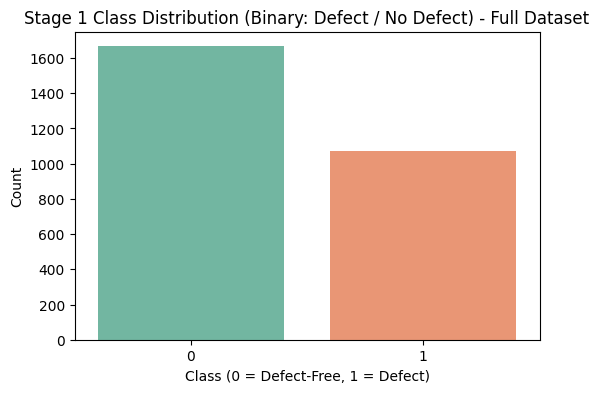

Defect-Free: 1666, Defect: 1073


In [26]:
import torch

# Stage 1: full dataset labels (0 = defect-free, 1 = defect)
stage1_labels = [label for _, label in dataset_stage1.samples]

plt.figure(figsize=(6,4))
sns.countplot(x=stage1_labels, palette="Set2")
plt.title("Stage 1 Class Distribution (Binary: Defect / No Defect) - Full Dataset")
plt.xlabel("Class (0 = Defect-Free, 1 = Defect)")
plt.ylabel("Count")
plt.show()

# Print counts
counts_stage1 = torch.bincount(torch.tensor(stage1_labels))
print(f"Defect-Free: {counts_stage1[0]}, Defect: {counts_stage1[1]}")


Stage 2 Class distribution

C:\Users\r\AppData\Local\Temp\ipykernel_4668\378222133.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=stage2_labels_named, palette="Set3")


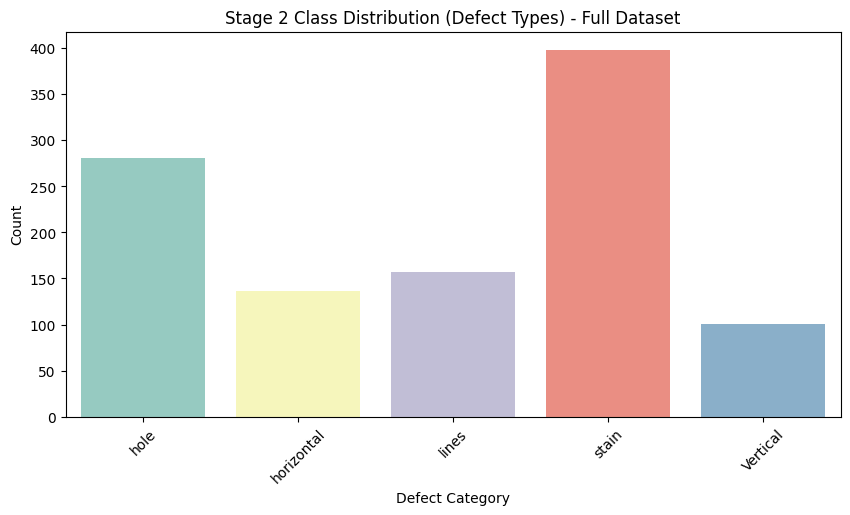

stain         398
hole          281
lines         157
horizontal    136
Vertical      101
Name: count, dtype: int64


In [27]:
# Stage 2: full dataset labels (integer indices)
stage2_labels = [dataset_stage2.class_to_idx[label] for _, label in dataset_stage2.samples]
stage2_labels_named = [idx_to_class_stage2[i] for i in stage2_labels]

plt.figure(figsize=(10,5))
sns.countplot(x=stage2_labels_named, palette="Set3")
plt.title("Stage 2 Class Distribution (Defect Types) - Full Dataset")
plt.xlabel("Defect Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Print counts per class
import pandas as pd
counts_stage2 = pd.Series(stage2_labels_named).value_counts()
print(counts_stage2)


Stage 1 Confusion Matrix

<Figure size 500x500 with 0 Axes>

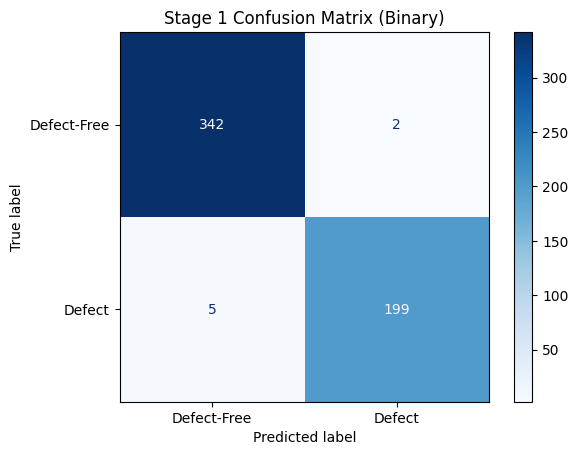

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Get predictions and true labels for Stage 1 validation set
all_labels_stage1 = []
all_preds_stage1 = []

model_stage1.eval()
with torch.no_grad():
    for images, labels in val_loader_stage1:
        images, labels = images.to(device), labels.to(device)
        outputs = model_stage1(images)
        preds = torch.argmax(outputs, dim=1)
        
        all_labels_stage1.extend(labels.cpu().numpy())
        all_preds_stage1.extend(preds.cpu().numpy())

# Compute confusion matrix
cm_stage1 = confusion_matrix(all_labels_stage1, all_preds_stage1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_stage1, display_labels=["Defect-Free", "Defect"])

plt.figure(figsize=(5,5))
disp.plot(cmap="Blues", values_format='d')
plt.title("Stage 1 Confusion Matrix (Binary)")
plt.show()


Stage 2 Confusion Matrix

<Figure size 1000x800 with 0 Axes>

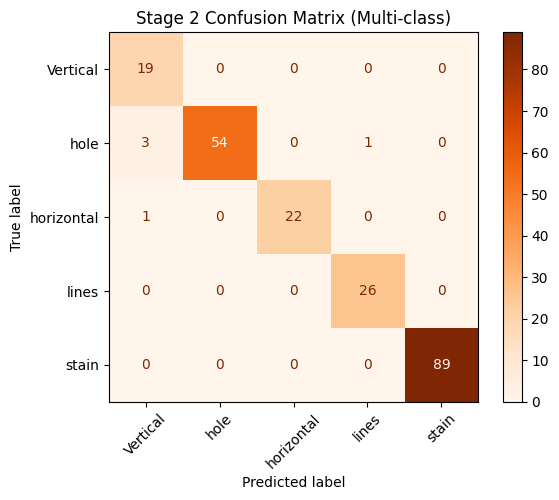

In [29]:
# Get predictions and true labels for Stage 2 validation set
all_labels_stage2 = []
all_preds_stage2 = []

model_stage2.eval()
with torch.no_grad():
    for images, labels in val_loader_stage2:
        images, labels = images.to(device), labels.to(device)
        outputs = model_stage2(images)
        preds = torch.argmax(outputs, dim=1)
        
        all_labels_stage2.extend(labels.cpu().numpy())
        all_preds_stage2.extend(preds.cpu().numpy())

# Compute confusion matrix
cm_stage2 = confusion_matrix(all_labels_stage2, all_preds_stage2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_stage2, display_labels=dataset_stage2.classes)

plt.figure(figsize=(10,8))
disp2.plot(cmap="Oranges", values_format='d', xticks_rotation=45)
plt.title("Stage 2 Confusion Matrix (Multi-class)")
plt.show()


Stage 1 ROC & PR Curves

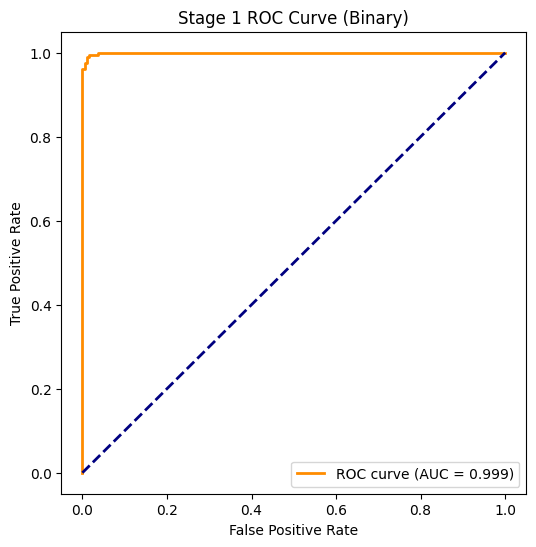

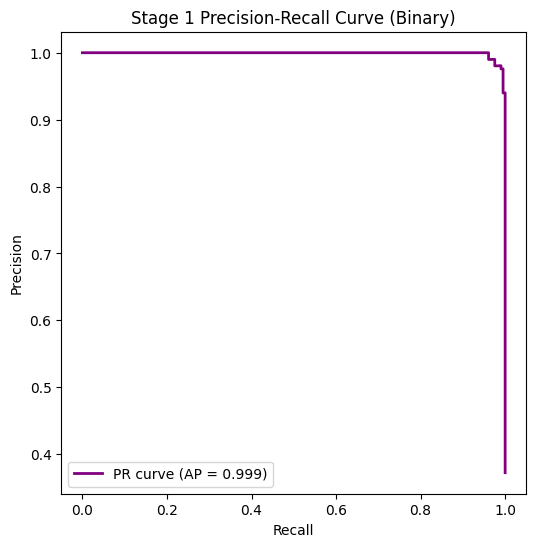

In [30]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Get predictions and true labels for Stage 1 validation set
all_labels_stage1 = []
all_probs_stage1 = []

model_stage1.eval()
with torch.no_grad():
    for images, labels in val_loader_stage1:
        images, labels = images.to(device), labels.to(device)
        outputs = model_stage1(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # probability of class 1 (defect)
        
        all_labels_stage1.extend(labels.cpu().numpy())
        all_probs_stage1.extend(probs.cpu().numpy())

# Convert to numpy arrays
all_labels_stage1 = np.array(all_labels_stage1)
all_probs_stage1 = np.array(all_probs_stage1)

# ---- ROC Curve ----
fpr, tpr, thresholds = roc_curve(all_labels_stage1, all_probs_stage1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Stage 1 ROC Curve (Binary)')
plt.legend(loc='lower right')
plt.show()

# ---- Precision-Recall Curve ----
precision, recall, thresholds_pr = precision_recall_curve(all_labels_stage1, all_probs_stage1)
avg_precision = average_precision_score(all_labels_stage1, all_probs_stage1)

plt.figure(figsize=(6,6))
plt.plot(recall, precision, color='purple', lw=2, label=f'PR curve (AP = {avg_precision:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Stage 1 Precision-Recall Curve (Binary)')
plt.legend(loc='lower left')
plt.show()


Stage 2 ROC & PR Curves (Multi-class)

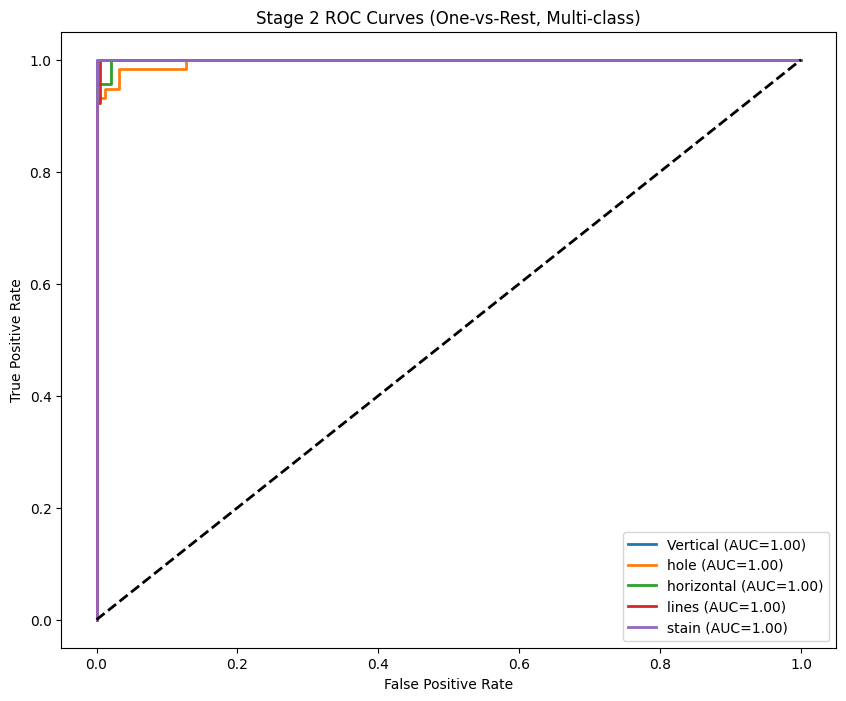

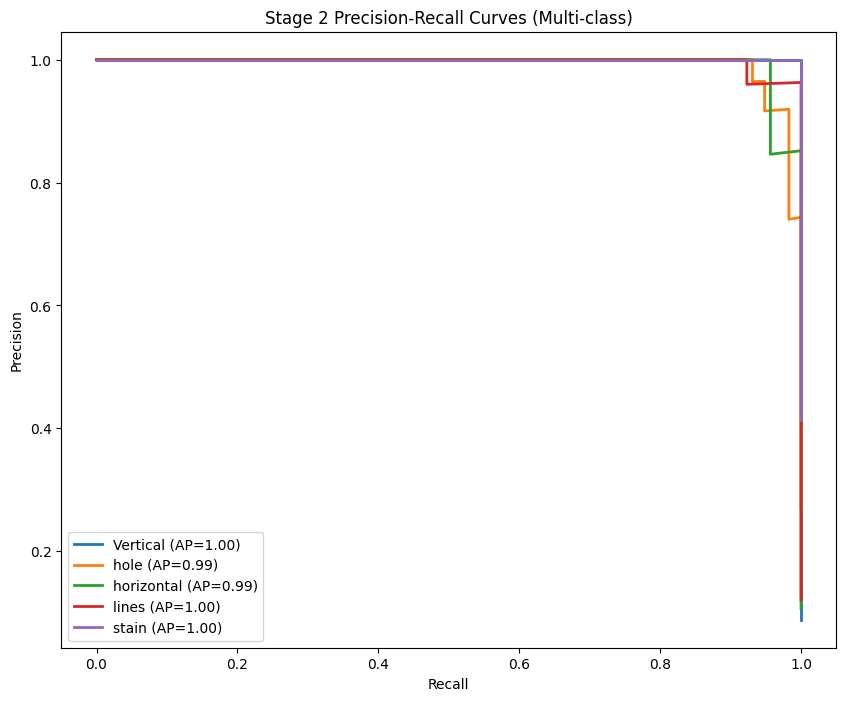

In [31]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# Get predictions and true labels for Stage 2 validation set
all_labels_stage2 = []
all_probs_stage2 = []

model_stage2.eval()
with torch.no_grad():
    for images, labels in val_loader_stage2:
        images, labels = images.to(device), labels.to(device)
        outputs = model_stage2(images)
        probs = torch.softmax(outputs, dim=1)
        
        all_labels_stage2.extend(labels.cpu().numpy())
        all_probs_stage2.extend(probs.cpu().numpy())

# Convert to numpy arrays
all_labels_stage2 = np.array(all_labels_stage2)
all_probs_stage2 = np.array(all_probs_stage2)

# Binarize labels for multi-class ROC
all_labels_bin = label_binarize(all_labels_stage2, classes=range(num_classes_stage2))

# Plot ROC curves for each class
plt.figure(figsize=(10,8))
for i in range(num_classes_stage2):
    fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs_stage2[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{dataset_stage2.classes[i]} (AUC={roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Stage 2 ROC Curves (One-vs-Rest, Multi-class)')
plt.legend(loc='lower right')
plt.show()

# Precision-Recall curve for each class
plt.figure(figsize=(10,8))
for i in range(num_classes_stage2):
    precision, recall, _ = precision_recall_curve(all_labels_bin[:, i], all_probs_stage2[:, i])
    avg_precision = average_precision_score(all_labels_bin[:, i], all_probs_stage2[:, i])
    plt.plot(recall, precision, lw=2, label=f'{dataset_stage2.classes[i]} (AP={avg_precision:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Stage 2 Precision-Recall Curves (Multi-class)')
plt.legend(loc='lower left')
plt.show()


Stage 2 Feature Embeddings (t-SNE)

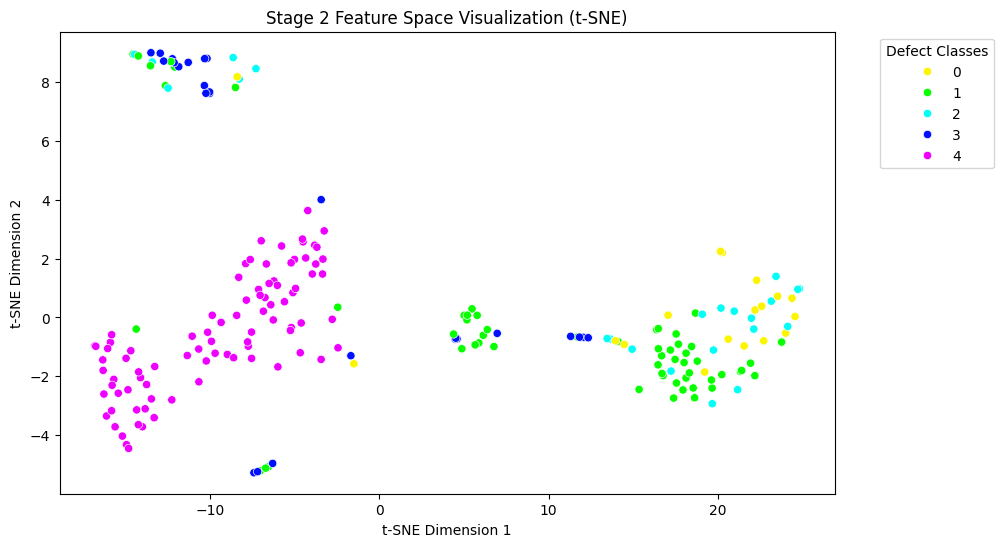

In [32]:
from sklearn.manifold import TSNE
import numpy as np

# Extract features from the backbone before the final layer
model_stage2.eval()
features = []
labels_tsne = []

with torch.no_grad():
    for images, labels in val_loader_stage2:
        images = images.to(device)
        # Get features before the final fully connected layer
        feat = model_stage2.backbone.avgpool(model_stage2.backbone.layer4(
                    model_stage2.backbone.layer3(
                        model_stage2.backbone.layer2(
                            model_stage2.backbone.layer1(
                                model_stage2.backbone.conv1(images)
                            )
                        )
                    )
                )
            )
        feat = torch.flatten(feat, 1)  # flatten
        features.append(feat.cpu().numpy())
        labels_tsne.extend(labels.numpy())

features = np.concatenate(features, axis=0)
labels_tsne = np.array(labels_tsne)

# t-SNE
tsne = TSNE(n_components=2, random_state=42)
features_2d = tsne.fit_transform(features)

# Plot
plt.figure(figsize=(10,6))
palette = sns.color_palette("hsv", n_colors=len(dataset_stage2.classes))
sns.scatterplot(x=features_2d[:,0], y=features_2d[:,1], hue=labels_tsne, palette=palette, legend='full')
plt.title("Stage 2 Feature Space Visualization (t-SNE)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title="Defect Classes", bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()


Grad-CAM for Stage 2

c:\ProgramData\anaconda3\envs\fabric_gpu\lib\site-packages\torch\nn\modules\module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


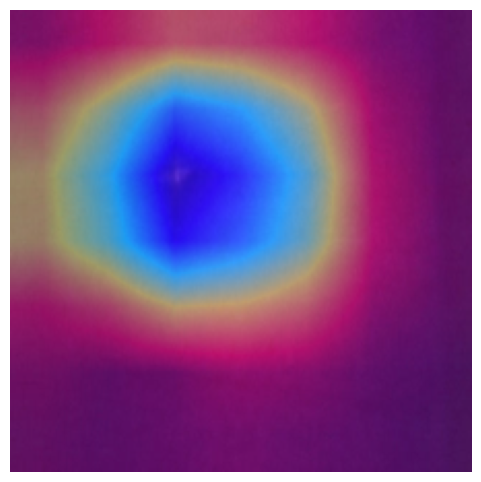

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

def grad_cam(model, image, target_class, device, layer_name='layer4'):
    model.eval()
    
    # Forward hook to capture activations
    activations = {}
    def forward_hook(module, input, output):
        activations['value'] = output

    # Backward hook to capture gradients
    gradients = {}
    def backward_hook(module, grad_in, grad_out):
        gradients['value'] = grad_out[0]

    # Register hooks
    target_layer = getattr(model.backbone, layer_name)
    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_backward_hook(backward_hook)

    image = image.unsqueeze(0).to(device)
    output = model(image)
    loss = output[0, target_class]
    model.zero_grad()
    loss.backward()

    # Get gradients and activations
    grad = gradients['value'].cpu().data.numpy()[0]
    act = activations['value'].cpu().data.numpy()[0]
    weights = np.mean(grad, axis=(1,2))
    cam = np.zeros(act.shape[1:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * act[i, :, :]

    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (image.size(3), image.size(2)))
    cam -= cam.min()
    cam /= cam.max()

    forward_handle.remove()
    backward_handle.remove()
    
    return cam

def show_grad_cam(image_tensor, cam):
    img = image_tensor.permute(1,2,0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())
    heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    overlay = heatmap + img
    overlay = overlay / overlay.max()
    plt.figure(figsize=(6,6))
    plt.imshow(overlay)
    plt.axis('off')
    plt.show()

# Example: pick a random sample from Stage 2 validation set
sample_img, sample_label = val_dataset_stage2[0]
cam = grad_cam(model_stage2, sample_img, target_class=sample_label, device=device)
show_grad_cam(sample_img, cam)


Two-Stage Combined Confusion Matrix

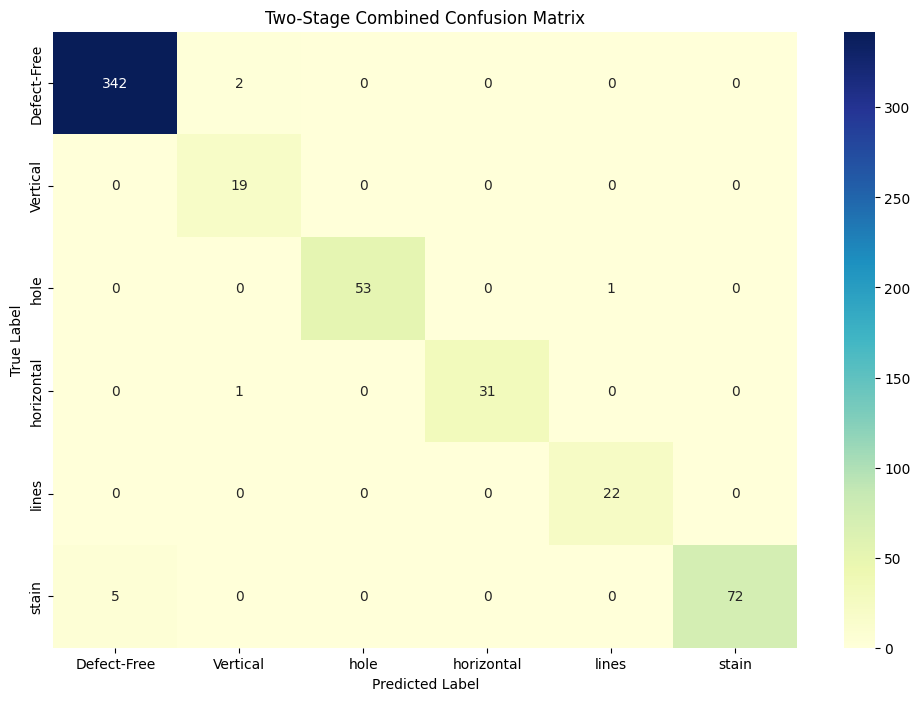

In [47]:
# Build mapping from Stage1 index -> Stage2 label
stage1_idx_to_stage2_label = {}
for i, (path, label) in enumerate(dataset_stage1.samples):
    if label == 1:  # defective
        # Stage2 label for this defect image
        stage2_label = dataset_stage2.class_to_idx[path.split(os.sep)[-2]]  # folder name
        stage1_idx_to_stage2_label[i] = stage2_label

num_stage2_classes = len(dataset_stage2.classes)
num_classes = num_stage2_classes + 1  # +1 for defect-free
combined_cm = np.zeros((num_classes, num_classes), dtype=int)

model_stage1.eval()
model_stage2.eval()
with torch.no_grad():
    for batch_indices, (images, labels_stage1) in enumerate(val_loader_stage1):
        images = images.to(device)
        labels_stage1 = labels_stage1.to(device)
        preds_stage1 = torch.argmax(model_stage1(images), dim=1)
        
        for j in range(len(labels_stage1)):
            stage1_idx = val_dataset_stage1.indices[batch_indices * val_loader_stage1.batch_size + j]
            stage1_label = labels_stage1[j].item()
            stage1_pred = preds_stage1[j].item()
            
            if stage1_label == 0:  # defect-free
                combined_cm[0, 0 if stage1_pred == 0 else 1] += 1
            else:  # defective
                true_stage2_label = stage1_idx_to_stage2_label[stage1_idx]
                if stage1_pred == 0:  # misclassified as defect-free
                    combined_cm[true_stage2_label + 1, 0] += 1
                else:
                    stage2_pred = torch.argmax(model_stage2(images[j].unsqueeze(0)), dim=1).item()
                    combined_cm[true_stage2_label + 1, stage2_pred + 1] += 1

# Class names
class_names = ["Defect-Free"] + dataset_stage2.classes

plt.figure(figsize=(12,8))
sns.heatmap(combined_cm, annot=True, fmt="d", cmap="YlGnBu",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Two-Stage Combined Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [48]:
from sklearn.metrics import precision_recall_fscore_support

# Stage 1 Accuracy (Binary)
acc_stage1 = evaluate_stage1(model_stage1, val_loader_stage1, device)

# Stage 2 Accuracy (Multi-class)
acc_stage2 = evaluate_stage2(model_stage2, val_loader_stage2, device)

# Combined Two-Stage Accuracy
acc_combined = evaluate_two_stage(model_stage1, model_stage2, val_loader_stage1, val_loader_stage2, device)


Stage 1 Accuracy (Binary): 0.9872
Stage 2 Accuracy (Multi-class): 0.9767
Overall Two-Stage Accuracy: 0.6606


Stage 1 Recall for Defective Samples: 0.9755


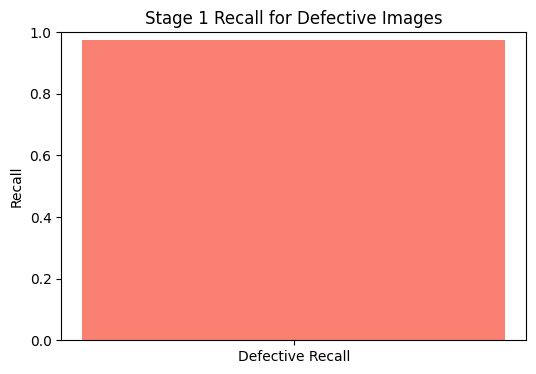

In [50]:
import matplotlib.pyplot as plt

# Stage 1 recall for defective images
model_stage1.eval()
total_defective = 0
correct_defective = 0

with torch.no_grad():
    for images, labels in val_loader_stage1:
        images, labels = images.to(device), labels.to(device)
        preds = torch.argmax(model_stage1(images), dim=1)
        for i in range(len(labels)):
            if labels[i] == 1:  # defective
                total_defective += 1
                if preds[i] == 1:  # correctly identified as defective
                    correct_defective += 1

stage1_defective_recall = correct_defective / total_defective
print(f"Stage 1 Recall for Defective Samples: {stage1_defective_recall:.4f}")

# Visualization
plt.figure(figsize=(6,4))
plt.bar(['Defective Recall'], [stage1_defective_recall], color='salmon')
plt.ylim(0,1)
plt.title('Stage 1 Recall for Defective Images')
plt.ylabel('Recall')
plt.show()


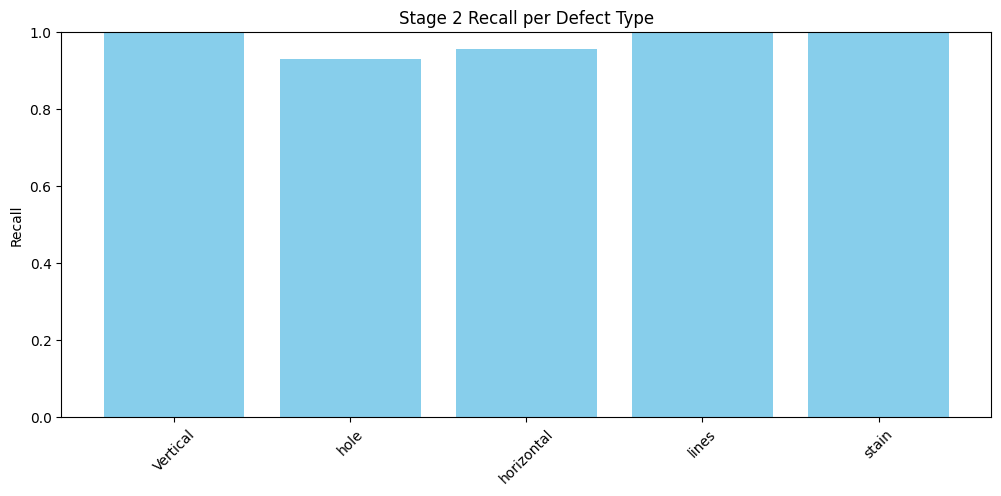

In [51]:
num_defect_classes = len(dataset_stage2.classes)
stage2_correct = [0] * num_defect_classes
stage2_total = [0] * num_defect_classes

model_stage2.eval()
with torch.no_grad():
    for images, labels in val_loader_stage2:
        images, labels = images.to(device), labels.to(device)
        preds = torch.argmax(model_stage2(images), dim=1)
        for i in range(len(labels)):
            stage2_total[labels[i].item()] += 1
            if preds[i] == labels[i]:
                stage2_correct[labels[i].item()] += 1

stage2_recall = [c/t if t>0 else 0 for c,t in zip(stage2_correct, stage2_total)]

# Plot
plt.figure(figsize=(12,5))
plt.bar(dataset_stage2.classes, stage2_recall, color='skyblue')
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.ylabel('Recall')
plt.title('Stage 2 Recall per Defect Type')
plt.show()
